In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (average_precision_score, roc_auc_score, fbeta_score,
                              precision_recall_curve, classification_report,
                              confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay)
from scipy.stats import mannwhitneyu
import joblib

pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42

## 1. Загрузка и первичный осмотр

In [3]:
data = pd.read_csv('../data/data.csv')
print(data.shape)
data.head()

(49995, 7)


,Customer_ID,Account_Age_Days,Transaction_Volume_USD,Avg_Time_Between_Trans_Min,Flags_Last_6M,Avg_End_Day_Balance,Is_Mule
0,CUST_115952,256.774261,3217.197454,5693.564680,0.0,NaN,0.0
1,CUST_86485,2767.326398,1191.370010,4481.447370,0.0,4550.932678,0.0
2,CUST_190866,1140.498927,1679.776881,4745.299392,0.0,4299.206502,0.0
3,CUST_65704,1549.189414,3607.315909,1775.782467,0.0,2788.692851,0.0
4,CUST_82071,1257.654514,NaN,5078.389943,0.0,7332.613297,0.0


In [4]:
data.isna().sum()

Customer_ID                   480
Account_Age_Days              499
Transaction_Volume_USD        499
Avg_Time_Between_Trans_Min    499
Flags_Last_6M                 499
Avg_End_Day_Balance           499
Is_Mule                       480
dtype: int64

## 2. Восстановление метки `Is_Mule`

`Is_Mule`  восстанавливается из префикса `Customer_ID`


строки без `Customer_ID` не имеют надёжной метки → они удаляются



In [5]:
before = len(data)
data = data.dropna(subset=['Customer_ID']).copy()
data['Is_Mule'] = data['Customer_ID'].str.contains('MULE').astype(int)
print(f"удалено строк без надёжной метки: {before - len(data)}")


real_dups = data.duplicated(subset=['Customer_ID']).sum()
print(f"реальных дублей Customer_ID: {real_dups}")
data = data.drop_duplicates(subset=['Customer_ID']).reset_index(drop=True)

data['Customer_type'] = data['Customer_ID'].str.split('_').str[0]
data['Is_Mule'].value_counts(normalize=True)

удалено строк без надёжной метки: 480
реальных дублей Customer_ID: 0


Is_Mule
0    0.949955
1    0.050045
Name: proportion, dtype: float64

## 3. Разбиение на train/val/test — до любого fit


`Customer_ID`/`Customer_type` тянем через весь пайплайн
только для диагностики (сегментный анализ)

`stratify=Is_Mule` сохраняет исходную пропорцию классов (~5%) в каждом
сплитe

In [6]:
train_df, temp_df = train_test_split(
    data, test_size=0.3, random_state=RANDOM_STATE, stratify=data['Is_Mule'])
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=RANDOM_STATE, stratify=temp_df['Is_Mule'])

print("train:", train_df.shape, train_df['Is_Mule'].mean())
print("val:  ", val_df.shape, val_df['Is_Mule'].mean())
print("test: ", test_df.shape, test_df['Is_Mule'].mean())

train: (34660, 8) 0.050057703404500865
val:   (7427, 8) 0.04995287464655985
test:  (7428, 8) 0.050080775444264945


## 4. EDA 

Cегментный анализ по
`Customer_type`, корреляции, boxplot/KDE, тест Манна-Уитни — оставляем,
но дополняем:

- проверкой **связи пропусков с таргетом** (не только с сегментом),
- явными **индикаторами пропуска** как потенциальными фичами,
- сравнением `MULE` 

In [7]:
RAW_NUM_COLS = ['Account_Age_Days', 'Transaction_Volume_USD',
                'Avg_Time_Between_Trans_Min', 'Flags_Last_6M', 'Avg_End_Day_Balance']

eda = train_df.copy()

print("доля пропусков по типу клиента:")
print(eda[RAW_NUM_COLS].isna().groupby(eda['Customer_type']).mean())

print("\nдоля пропусков среди Is_Mule=1 vs Is_Mule=0:")
print(eda[RAW_NUM_COLS].isna().groupby(eda['Is_Mule']).mean())

доля пропусков по типу клиента:
               Account_Age_Days  Transaction_Volume_USD  \
Customer_type                                             
CUST                   0.009460                0.010068   
MULE                   0.010951                0.010375   
TRADER                 0.011661                0.008784   

               Avg_Time_Between_Trans_Min  Flags_Last_6M  Avg_End_Day_Balance  
Customer_type                                                                  
CUST                             0.009612       0.010334             0.010296  
MULE                             0.010375       0.008646             0.007493  
TRADER                           0.009238       0.009995             0.011510  

доля пропусков среди Is_Mule=1 vs Is_Mule=0:
         Account_Age_Days  Transaction_Volume_USD  Avg_Time_Between_Trans_Min  \
Is_Mule                                                                         
0                0.009901                0.009810               

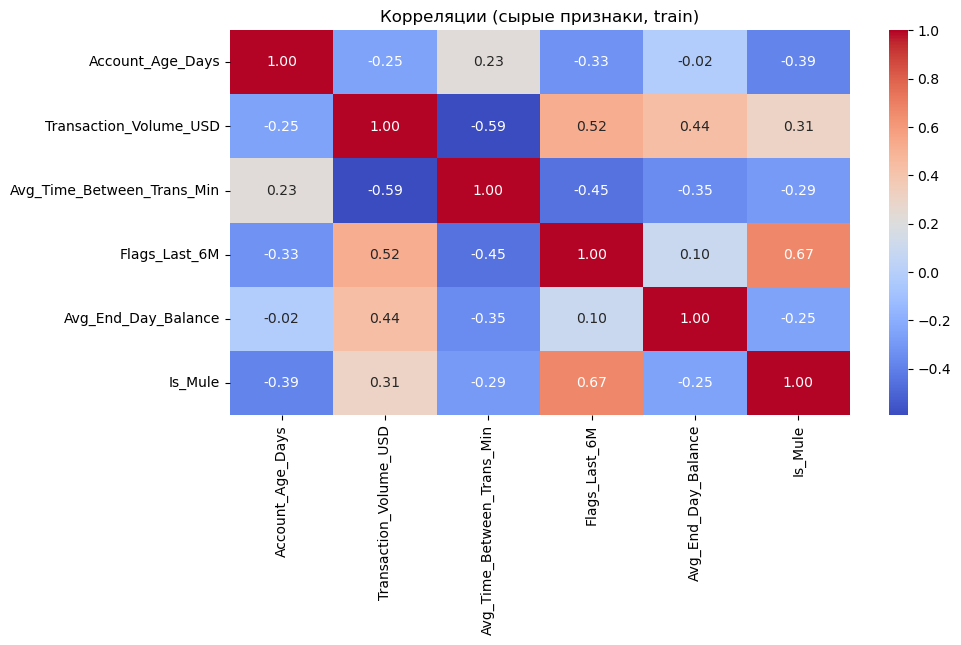

In [8]:
plt.figure(figsize=(10, 5))
sns.heatmap(eda[RAW_NUM_COLS + ['Is_Mule']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Корреляции (сырые признаки, train)')
plt.show()

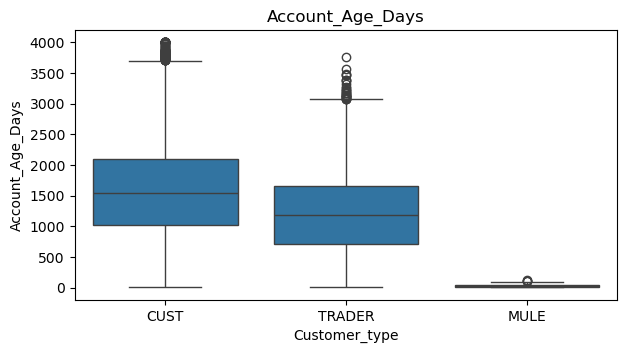

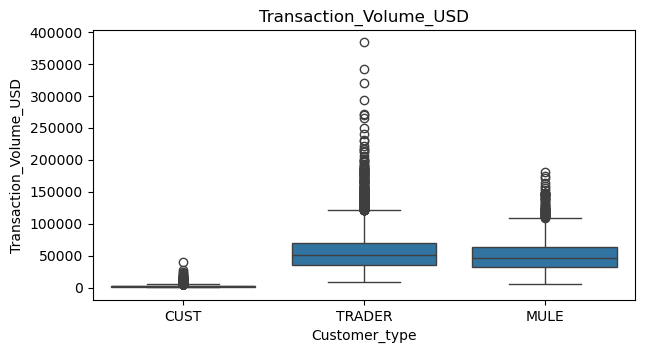

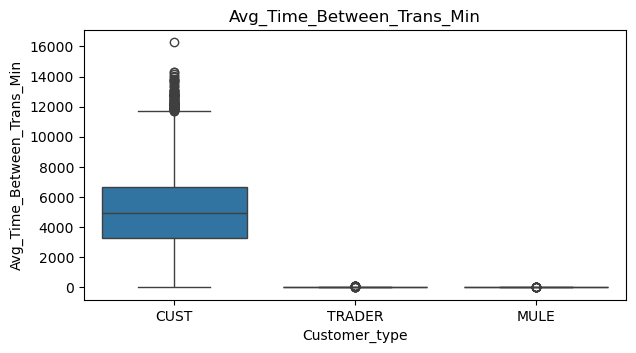

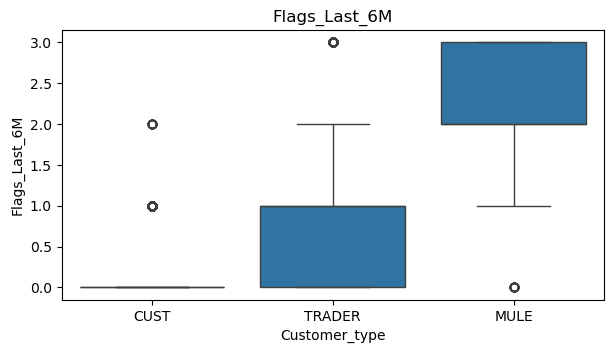

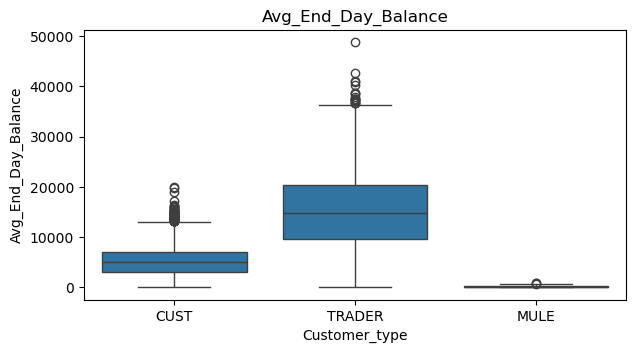

In [9]:
for col in RAW_NUM_COLS:
    plt.figure(figsize=(7, 3.5))
    sns.boxplot(x='Customer_type', y=col, data=eda)
    plt.title(col)
    plt.show()

In [10]:

mule = eda[eda['Customer_type'] == 'MULE']
cust = eda[eda['Customer_type'] == 'CUST']
trader = eda[eda['Customer_type'] == 'TRADER']

for col in RAW_NUM_COLS:
    p_cust = mannwhitneyu(mule[col].dropna(), cust[col].dropna()).pvalue
    p_trader = mannwhitneyu(mule[col].dropna(), trader[col].dropna()).pvalue
    print(f"{col:30s} MULE vs CUST p={p_cust:.2e} | MULE vs TRADER p={p_trader:.2e}")

Account_Age_Days               MULE vs CUST p=0.00e+00 | MULE vs TRADER p=0.00e+00
Transaction_Volume_USD         MULE vs CUST p=0.00e+00 | MULE vs TRADER p=2.00e-11
Avg_Time_Between_Trans_Min     MULE vs CUST p=0.00e+00 | MULE vs TRADER p=0.00e+00
Flags_Last_6M                  MULE vs CUST p=0.00e+00 | MULE vs TRADER p=0.00e+00
Avg_End_Day_Balance            MULE vs CUST p=0.00e+00 | MULE vs TRADER p=0.00e+00


**Что смотреть дополнительно перед моделированием** (помимо уже сделанного):

- Пересечение признаков "по объёму похож на TRADER, но по времени между
  транзакциями — как MULE" 

- Есть ли клиенты с `Flags_Last_6M > 0`, но не мошенники, и наоборот — это
  подсказывает, насколько само по себе `Flags_Last_6M` пригодно как признак

## 5. Импутация и скейлинг

KNNImputer работает по расстояниям, поэтому его нужно применять на
масштабированных данных.

In [11]:
def add_missing_flags(df):
    df = df.copy()
    for c in RAW_NUM_COLS:
        df[f'was_missing_{c}'] = df[c].isna().astype(int)
    return df

train_df = add_missing_flags(train_df)
val_df = add_missing_flags(val_df)
test_df = add_missing_flags(test_df)

scaler = StandardScaler().fit(train_df[RAW_NUM_COLS])
imputer = KNNImputer(n_neighbors=5)

def impute_scaled(df, fit=False):
    df = df.copy()
    scaled = scaler.transform(df[RAW_NUM_COLS])
    scaled_df = pd.DataFrame(scaled, columns=RAW_NUM_COLS, index=df.index)
    imputed = imputer.fit_transform(scaled_df) if fit else imputer.transform(scaled_df)
    df[RAW_NUM_COLS] = scaler.inverse_transform(imputed)
    return df

train_df = impute_scaled(train_df, fit=True)
val_df = impute_scaled(val_df, fit=False)
test_df = impute_scaled(test_df, fit=False)

train_df[RAW_NUM_COLS].isna().sum()

Account_Age_Days              0
Transaction_Volume_USD        0
Avg_Time_Between_Trans_Min    0
Flags_Last_6M                 0
Avg_End_Day_Balance           0
dtype: int64

## 6. Feature engineering

Твои три группы признаков (финансовые соотношения, скорость/частота,
риск-концентрация)

- `log1p` для тяжёлых хвостов (`Transaction_Volume_USD`, `Avg_End_Day_Balance`,
  `Daily_Volume`)

In [12]:
def engineer_features(df):
    df = df.copy()
    df['Balance_to_Volume_Ratio'] = df['Avg_End_Day_Balance'] / (df['Transaction_Volume_USD'] + 1)
    df['Volume_to_Balance_Ratio'] = df['Transaction_Volume_USD'] / (df['Avg_End_Day_Balance'] + 1)
    df['Daily_Volume'] = df['Transaction_Volume_USD'] / (df['Account_Age_Days'] + 1)
    df['Trans_Per_Hour'] = 60 / (df['Avg_Time_Between_Trans_Min'] + 1)
    df['Flags_per_Day'] = df['Flags_Last_6M'] / (df['Account_Age_Days'] + 1)
    for c in ['Transaction_Volume_USD', 'Avg_End_Day_Balance', 'Daily_Volume']:
        df[f'log_{c}'] = np.log1p(df[c])
    return df

train_df = engineer_features(train_df)
val_df = engineer_features(val_df)
test_df = engineer_features(test_df)

drop_cols = ['Customer_ID', 'Customer_type', 'Is_Mule']
feature_cols = [c for c in train_df.columns if c not in drop_cols]
print(len(feature_cols), 'признаков:', feature_cols)

X_train, y_train = train_df[feature_cols], train_df['Is_Mule']
X_val,   y_val   = val_df[feature_cols],   val_df['Is_Mule']
X_test,  y_test  = test_df[feature_cols],  test_df['Is_Mule']

18 признаков: ['Account_Age_Days', 'Transaction_Volume_USD', 'Avg_Time_Between_Trans_Min', 'Flags_Last_6M', 'Avg_End_Day_Balance', 'was_missing_Account_Age_Days', 'was_missing_Transaction_Volume_USD', 'was_missing_Avg_Time_Between_Trans_Min', 'was_missing_Flags_Last_6M', 'was_missing_Avg_End_Day_Balance', 'Balance_to_Volume_Ratio', 'Volume_to_Balance_Ratio', 'Daily_Volume', 'Trans_Per_Hour', 'Flags_per_Day', 'log_Transaction_Volume_USD', 'log_Avg_End_Day_Balance', 'log_Daily_Volume']


## 7. Модели и работа с дисбалансом классов

**Accuracy**: при ~5% мошенников модель, которая всегда
предсказывает "не мошенник", получит ~95% accuracy и 0% пользы. 

- **PR-AUC (average precision)** — основная метрика для выбора модели: она
  чувствительна именно к качеству на редком положительном классе, в отличие
  от ROC-AUC, который на сильном дисбалансе выглядит оптимистичнее, чем
  реальная полезность модели.
- **F2-score** — как рабочая метрика для подбора порога: recall (поймать
  дроппера) важнее precision, но не бесконечно — за счёт β=2 мы взвешиваем
  recall сильнее precision, но всё ещё штрафуем за огромное количество
  ложных блокировок.
- **Отдельно — FP-rate по сегменту `TRADER`** (не как фича, только как
  проверка): это прямая проверка бизнес-требования "не блокировать
  активных легитимных клиентов".

Модели: логическая регрессия как бейзлайн, random forest и xgboost. 
Дисбаланс не балансируем сэмплингом
искусственно (можно исказить границу трейдер/дроппер, которая и так тонкая),
а взвешиваем классы: `class_weight='balanced'` / `scale_pos_weight`.

In [13]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos

models = {
    'logreg': LogisticRegression(max_iter=3000, class_weight='balanced'),
    'random_forest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'xgboost': XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        scale_pos_weight=scale_pos_weight, eval_metric='aucpr', random_state=RANDOM_STATE),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_val)[:, 1]
    results[name] = {
        'model': model,
        'PR_AUC': average_precision_score(y_val, proba),
        'ROC_AUC': roc_auc_score(y_val, proba),
        'F2@0.5': fbeta_score(y_val, (proba >= 0.5).astype(int), beta=2),
    }

pd.DataFrame({k: {m: v for m, v in r.items() if m != 'model'} for k, r in results.items()}).T

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,PR_AUC,ROC_AUC,F2@0.5
logreg,0.999220,0.999949,0.990364
random_forest,0.999913,0.999995,0.987020
xgboost,0.999929,0.999996,0.996767


### 7.1 Проверка: метрики идеальны из-за данных или из-за утечки?

`PR-AUC ≈ 1.0` на валидации — нужно проверить. Обучаем те же
модели **только на пяти сырых признаках** 

In [14]:
from sklearn.metrics import average_precision_score as _ap

raw_check_model = RandomForestClassifier(
    n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
raw_check_model.fit(X_train[RAW_NUM_COLS], y_train)
raw_proba_val = raw_check_model.predict_proba(X_val[RAW_NUM_COLS])[:, 1]

print(f"PR-AUC только на 5 сырых признаках: {_ap(y_val, raw_proba_val):.6f}")
best_full_pr_auc = max(r['PR_AUC'] for r in results.values())
print(f"PR-AUC лучшей модели со всеми {len(feature_cols)} признаками: {best_full_pr_auc:.6f}")

PR-AUC только на 5 сырых признаках: 0.997296
PR-AUC лучшей модели со всеми 18 признаками: 0.999929


## 8. Выбор лучшей модели и порога классификации

Модель выбираем по **PR-AUC на валидации** (не на train — иначе переобучение
не увидим). Порог — отдельная настройка поверх лучшей модели: 0.5 почти
всегда не оптимален при дисбалансе, подбираем порог, максимизирующий F2 на
той же валидационной выборке.

лучшая модель по PR-AUC на валидации: xgboost
порог, максимизирующий F2 на валидации: 0.6625


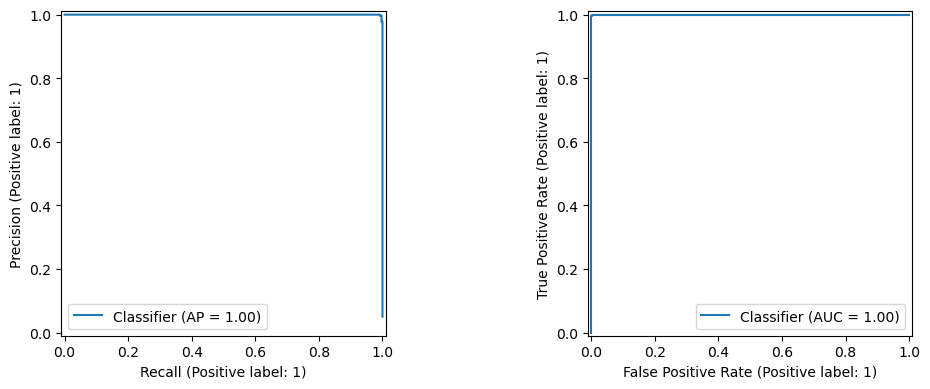

In [15]:
best_name = max(results, key=lambda k: results[k]['PR_AUC'])
best_model = results[best_name]['model']
print('лучшая модель по PR-AUC на валидации:', best_name)

proba_val = best_model.predict_proba(X_val)[:, 1]
prec, rec, thr = precision_recall_curve(y_val, proba_val)
f2_curve = (5 * prec * rec) / (4 * prec + rec + 1e-9)
best_thr = thr[np.argmax(f2_curve[:-1])]
print('порог, максимизирующий F2 на валидации:', round(best_thr, 4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
PrecisionRecallDisplay.from_predictions(y_val, proba_val, ax=axes[0])
RocCurveDisplay.from_predictions(y_val, proba_val, ax=axes[1])
plt.tight_layout()
plt.show()

## 9. Финальная проверка на test (не трогали до этого момента)

In [16]:
proba_test = best_model.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= best_thr).astype(int)

print(classification_report(y_test, pred_test, digits=3))
print('confusion matrix:\n', confusion_matrix(y_test, pred_test))

seg = test_df.copy()
seg['pred'] = pred_test
print('\nдоля заблокированных по сегментам (бизнес-проверка):')
print(seg.groupby('Customer_type')['pred'].mean())

              precision    recall  f1-score   support

           0      1.000     1.000     1.000      7056
           1      0.997     0.997     0.997       372

    accuracy                          1.000      7428
   macro avg      0.999     0.999     0.999      7428
weighted avg      1.000     1.000     1.000      7428

confusion matrix:
 [[7055    1]
 [   1  371]]

доля заблокированных по сегментам (бизнес-проверка):
Customer_type
CUST      0.000000
MULE      0.997312
TRADER    0.000725
Name: pred, dtype: float64


## 10. Интерпретируемость:



- **Встроенная важность признаков** (быстрый общий взгляд, но искажена в
  сторону высококардинальных числовых признаков у деревьев).
- **Permutation importance** на валидации — честнее показывает, какие
  признаки реально дают прирост качества, а не просто чаще используются
  в сплитах.
- **SHAP** — какие признаки в целом важны

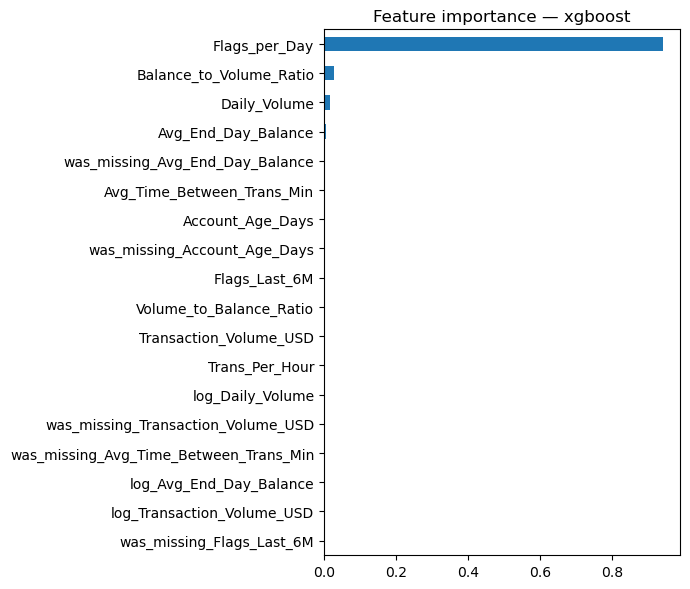

In [17]:
import shap

importances = pd.Series(best_model.feature_importances_, index=feature_cols) \
    if hasattr(best_model, 'feature_importances_') else \
    pd.Series(np.abs(best_model.coef_[0]), index=feature_cols)
importances.sort_values().plot(kind='barh', figsize=(7, 6), title=f'Feature importance — {best_name}')
plt.tight_layout()
plt.show()

### 10.1 Permutation importance — не держится ли всё на одном признаке?

Встроенная важность дерева (выше) искажена в сторону признаков с большим
числом уникальных значений.

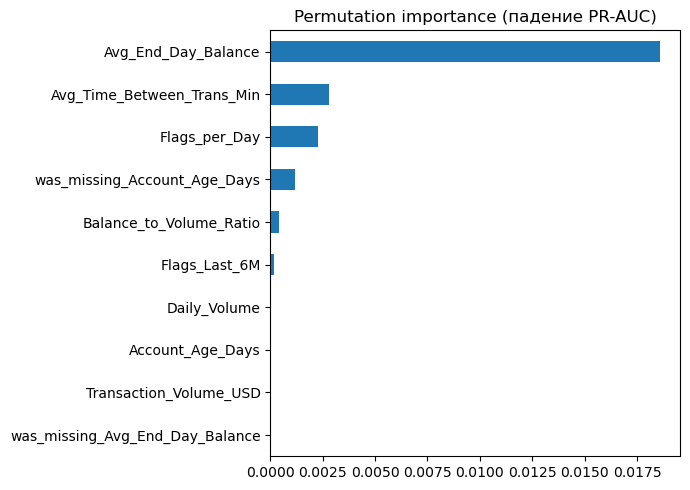

Avg_End_Day_Balance                0.018620
Avg_Time_Between_Trans_Min         0.002783
Flags_per_Day                      0.002273
was_missing_Account_Age_Days       0.001158
Balance_to_Volume_Ratio            0.000434
Flags_Last_6M                      0.000190
Daily_Volume                       0.000051
Account_Age_Days                   0.000031
Transaction_Volume_USD             0.000028
was_missing_Avg_End_Day_Balance    0.000014
dtype: float64


In [18]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_model, X_val, y_val, scoring='average_precision',
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)

perm_importance = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=False)
perm_importance.head(10).plot(kind='barh', figsize=(7, 5), title='Permutation importance (падение PR-AUC)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(perm_importance.head(10))

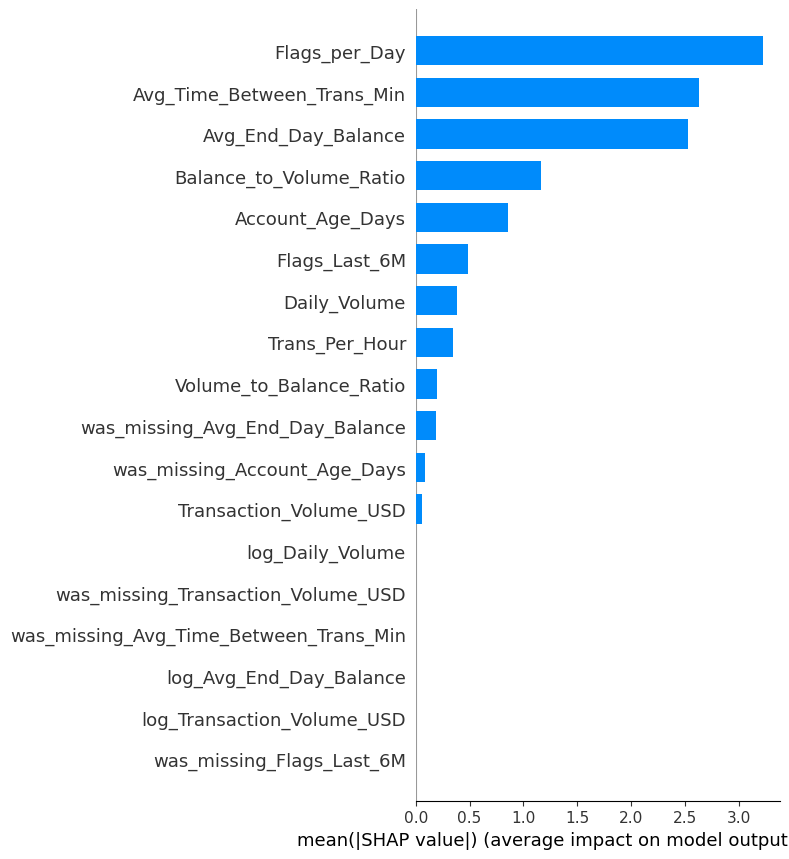

In [ ]:
def get_positive_class_shap(shap_values):
    if isinstance(shap_values, list):
        return shap_values[1]
    if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        return shap_values[:, :, 1]
    return shap_values

explainer = shap.TreeExplainer(best_model) if best_name in ('random_forest', 'xgboost') \
    else shap.LinearExplainer(best_model, X_train)
shap_values = explainer.shap_values(X_val)
shap_vals_pos = get_positive_class_shap(shap_values)

shap.summary_plot(shap_vals_pos, X_val, plot_type='bar', show=False)
plt.tight_layout()
plt.show()

In [ ]:

flagged_idx = np.where(pred_test == 1)[0][0]
row = X_test.iloc[[flagged_idx]]
row_shap = get_positive_class_shap(explainer.shap_values(row))

explanation = pd.Series(row_shap[0], index=feature_cols).sort_values(key=abs, ascending=False)
print('вклад признаков в решение по конкретному клиенту:')
print(explanation.head(8))

вклад признаков в решение по конкретному клиенту:
Flags_per_Day                 4.296964
Daily_Volume                  2.327237
Account_Age_Days              1.483503
Avg_Time_Between_Trans_Min    1.345981
Avg_End_Day_Balance           1.095178
Balance_to_Volume_Ratio       0.865132
Trans_Per_Hour                0.331988
Volume_to_Balance_Ratio       0.316106
dtype: float32


## 11. Устойчивость: проблема в датасете, а не в выборе алгоритма

Мы выяснили, что решение почти целиком опирается на `Account_Age_Days` и
`Avg_Time_Between_Trans_Min` (плюс их прямые производные — `Trans_Per_Hour`,
`Daily_Volume`, `log_Daily_Volume`, которые несут ту же информацию в другой
форме, поэтому их тоже исключаем). Прежде чем "чинить" модель, нужно сначала
доказать, что дело не в том, что мы выбрали неудачный алгоритм.

**Проверка:** обучаем несколько принципиально разных семейств моделей
(линейная модель, два разных ансамбля деревьев) **без двух доминирующих
признаков и их производных**, и меряем качество не в целом (общий PR-AUC
завышен, потому что `CUST` и так легко отделяется по объёму/балансу), а
конкретно на самой сложной подзадаче — **отличить `MULE` от `TRADER`**,
у которых объём и баланс похожи, но разный сценарий использования счёта.
Если все алгоритмы одинаково "просядут" на этой подзадаче — значит проблема
не в модели, а в том, что оставшиеся признаки физически не содержат нужного
сигнала.

In [21]:
from sklearn.ensemble import GradientBoostingClassifier

DOMINANT_AND_DERIVED = ['Account_Age_Days', 'Avg_Time_Between_Trans_Min',
                         'Trans_Per_Hour', 'Daily_Volume', 'log_Daily_Volume']
remaining_feats = [c for c in feature_cols if c not in DOMINANT_AND_DERIVED]

# самая сложная подвыборка: только MULE и TRADER (CUST убираем, чтобы не завышать метрику)
val_hard_mask = val_df['Customer_type'].isin(['MULE', 'TRADER'])
X_val_hard = X_val.loc[val_hard_mask, remaining_feats]
y_val_hard = (val_df.loc[val_hard_mask, 'Customer_type'] == 'MULE').astype(int)

candidate_models = {
    'logreg':          LogisticRegression(max_iter=3000, class_weight='balanced'),
    'random_forest':   RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                               random_state=RANDOM_STATE, n_jobs=-1),
    'xgboost':         XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                                      scale_pos_weight=scale_pos_weight, eval_metric='aucpr',
                                      random_state=RANDOM_STATE),
    'gradient_boost':  GradientBoostingClassifier(random_state=RANDOM_STATE),
}

hard_task_scores = {}
for name, m in candidate_models.items():
    m.fit(X_train[remaining_feats], y_train)
    proba_hard = m.predict_proba(X_val_hard)[:, 1]
    hard_task_scores[name] = average_precision_score(y_val_hard, proba_hard)

print("PR-AUC на подзадаче 'MULE vs TRADER', без двух доминирующих признаков:")
for name, score in hard_task_scores.items():
    print(f"  {name:16s}: {score:.3f}")
print(f"\nдля сравнения — та же подзадача, но с доминирующими признаками (лучшая модель): "
      f"{average_precision_score(y_val_hard, best_model.predict_proba(X_val.loc[val_hard_mask])[:, 1]):.3f}")

PR-AUC на подзадаче 'MULE vs TRADER', без двух доминирующих признаков:
  logreg          : 0.983
  random_forest   : 0.999
  xgboost         : 0.999
  gradient_boost  : 0.999

для сравнения — та же подзадача, но с доминирующими признаками (лучшая модель): 1.000


### 11.1 Что можно сделать на уровне модели

Раз проблема — в недостатке независимого сигнала в оставшихся признаках,
алгоритмически её можно **смягчить**, но не устранить полностью:

1. **Убрать признаки-дубликаты** (`Trans_Per_Hour`, `Daily_Volume`,
   `log_Daily_Volume`) — они не несут новой информации, только зашумляют
   интерпретацию и permutation importance.
2. **Ограничить долю признаков на каждое разбиение дерева**
   (`max_features`/`colsample_bytree` < 1.0) — это не создаёт новый сигнал,
   но заставляет часть деревьев ансамбля строить сплиты без доступа к топ-2
   признакам, вынуждая их находить хоть какую-то пользу в остальных 13.
3. **Ансамбль "defense in depth"**: обучаем основную модель как раньше и
   отдельную дополнительную модель **только на `remaining_feats`**
   (без доминирующих признаков) — это модель, которая опирается ровно на
   то немногое, что осталось. Комбинируем два скора (берём максимум) —
   так протокол ловит либо явную аномалию по возрасту/скорости, либо
   слабую, но всё же существующую аномалию по остальным признакам.

Это не сделает модель непробиваемой — п.11 выше уже показал, что резерв
сигнала в оставшихся признаках слабый (у всех алгоритмов). Но это честная,
проверяемая мера — и именно поэтому её стоит показать на защите как
"меру снижения риска", а не как "решённую проблему".

In [ ]:
robust_primary = RandomForestClassifier(
    n_estimators=300, max_features=0.5, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1)
robust_primary.fit(X_train[feature_cols], y_train)

fallback_model = RandomForestClassifier(
    n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
fallback_model.fit(X_train[remaining_feats], y_train)

proba_primary_val = robust_primary.predict_proba(X_val[feature_cols])[:, 1]
proba_fallback_val = fallback_model.predict_proba(X_val[remaining_feats])[:, 1]
proba_combined_val = np.maximum(proba_primary_val, proba_fallback_val)

print(f"PR-AUC основной модели (max_features=0.5):     {average_precision_score(y_val, proba_primary_val):.6f}")
print(f"PR-AUC резервной модели (без топ-2 признаков):  {average_precision_score(y_val, proba_fallback_val):.6f}")
print(f"PR-AUC комбинированной схемы (max скор):        {average_precision_score(y_val, proba_combined_val):.6f}")

PR-AUC основной модели (max_features=0.5):     0.999964
PR-AUC резервной модели (без топ-2 признаков):  0.999255
PR-AUC комбинированной схемы (max скор):        0.999776


### 11.2 Финализируем комбинированную схему: порог и проверка на test


In [23]:
prec_c, rec_c, thr_c = precision_recall_curve(y_val, proba_combined_val)
f2_c = (5 * prec_c * rec_c) / (4 * prec_c + rec_c + 1e-9)
combined_thr = thr_c[np.argmax(f2_c[:-1])]
print('порог для комбинированной схемы (F2 на валидации):', round(combined_thr, 4))

proba_primary_test = robust_primary.predict_proba(X_test[feature_cols])[:, 1]
proba_fallback_test = fallback_model.predict_proba(X_test[remaining_feats])[:, 1]
proba_combined_test = np.maximum(proba_primary_test, proba_fallback_test)
pred_combined_test = (proba_combined_test >= combined_thr).astype(int)

print(classification_report(y_test, pred_combined_test, digits=3))

seg2 = test_df.copy()
seg2['pred'] = pred_combined_test
print('доля заблокированных по сегментам (комбинированная схема):')
print(seg2.groupby('Customer_type')['pred'].mean())

порог для комбинированной схемы (F2 на валидации): 0.4067
              precision    recall  f1-score   support

           0      1.000     1.000     1.000      7056
           1      0.995     0.997     0.996       372

    accuracy                          1.000      7428
   macro avg      0.997     0.999     0.998      7428
weighted avg      1.000     1.000     1.000      7428

доля заблокированных по сегментам (комбинированная схема):
Customer_type
CUST      0.000000
MULE      0.997312
TRADER    0.001449
Name: pred, dtype: float64


## 12. Сохранение артефактов для MLOps


In [ ]:
import os

ARTIFACT_DIR = '../artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)          
ARTIFACT_PATH = os.path.join(ARTIFACT_DIR, 'aml_mule_pipeline.joblib')

joblib.dump({
    'scaler': scaler,
    'imputer': imputer,
    'primary_model': robust_primary,          # обучен на всех feature_cols, max_features=0.5
    'fallback_model': fallback_model,          # обучен только на remaining_feats (без топ-2 признаков)
    'feature_cols': feature_cols,
    'remaining_feats': remaining_feats,
    'raw_num_cols': RAW_NUM_COLS,
    'threshold': combined_thr,
    'inference_recipe': (
        "proba = max(primary_model.predict_proba(X[feature_cols])[:,1], "
        "fallback_model.predict_proba(X[remaining_feats])[:,1]); "
        "is_mule = proba >= threshold"
    ),
}, ARTIFACT_PATH)

print(f'сохранено: {ARTIFACT_PATH} (устойчивая ensemble-версия)')

сохранено: ../artifacts/aml_mule_pipeline.joblib (устойчивая ensemble-версия)
